
Eğitim Başlatılıyor: Baseline Kullanımı = True
Bölüm 300/1500	Ortalama Skor: 268.07
Bölüm 600/1500	Ortalama Skor: 371.57
Bölüm 900/1500	Ortalama Skor: 500.00
Bölüm 1200/1500	Ortalama Skor: 500.00
Bölüm 1500/1500	Ortalama Skor: 500.00

Eğitim Başlatılıyor: Baseline Kullanımı = False
Bölüm 300/1500	Ortalama Skor: 369.20
Bölüm 600/1500	Ortalama Skor: 96.40
Bölüm 900/1500	Ortalama Skor: 96.45
Bölüm 1200/1500	Ortalama Skor: 96.54
Bölüm 1500/1500	Ortalama Skor: 87.61


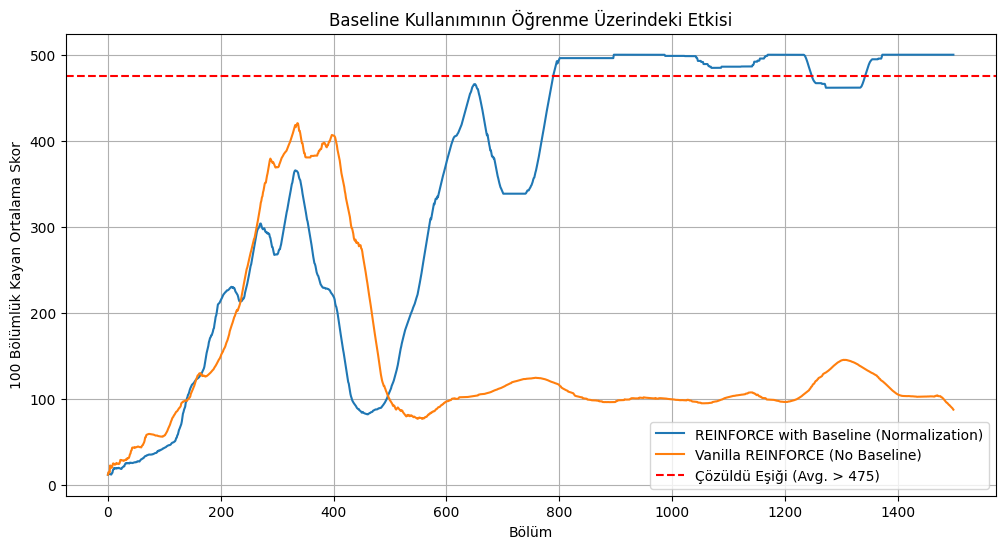

In [1]:
import gymnasium as gym
import torch
import numpy as np
import random
import os
import sys
from collections import deque
import matplotlib.pyplot as plt

# --- Proje Kök Dizinini Python Path'e Ekleme ---
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- Kendi Ajan Modülümüzü İçe Aktarma ---
from src.agents.simple_pg import ReinforceAgent

# --- Kurulum ve Seed Ayarları ---
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- Ortak Eğitim Fonksiyonu ---
def train_agent(use_baseline):
    """Belirtilen konfigürasyon ile REINFORCE ajanını eğitir ve skorları döndürür."""
    print(f"\nEğitim Başlatılıyor: Baseline Kullanımı = {use_baseline}")
    
    set_seed(42) # Her deneyi aynı rastgelelik koşullarında başlatmak için
    env = gym.make("CartPole-v1")
    obs_space_size = env.observation_space.shape[0]
    action_space_size = env.action_space.n
    agent = ReinforceAgent(obs_space_size, action_space_size, device, lr=0.005)

    total_episodes = 1500
    scores_deque = deque(maxlen=100)
    avg_scores = []
    
    for episode in range(1, total_episodes + 1):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.rewards.append(reward)
            episode_reward += reward
            state = next_state
        
        scores_deque.append(episode_reward)
        avg_scores.append(np.mean(scores_deque))
        
        # Bölüm sonunda politikayı güncelle
        agent.update_policy(use_baseline=use_baseline)
        
        if episode % 300 == 0:
            print(f'\rBölüm {episode}/{total_episodes}\tOrtalama Skor: {np.mean(scores_deque):.2f}')
            
    env.close()
    return avg_scores

# --- Deneyleri Çalıştır ---
scores_with_baseline = train_agent(use_baseline=True)
scores_without_baseline = train_agent(use_baseline=False)

# --- Sonuçları Görselleştirme ---
plt.figure(figsize=(12, 6))
plt.plot(scores_with_baseline, label='REINFORCE with Baseline (Normalization)')
plt.plot(scores_without_baseline, label='Vanilla REINFORCE (No Baseline)')
plt.title('Baseline Kullanımının Öğrenme Üzerindeki Etkisi')
plt.xlabel('Bölüm')
plt.ylabel('100 Bölümlük Kayan Ortalama Skor')
plt.axhline(y=475, color='r', linestyle='--', label='Çözüldü Eşiği (Avg. > 475)')
plt.legend()
plt.grid(True)
plt.show()

